In [1]:
import numpy as np

s = """#Arbitrary
# Column1 Column2
  1       11
  2       12
  3       13
  4       14
  5       15
  6       16
  7       17
  8       18
  9       19
  10      20
"""
f = open(s, 'w')
f.write(s)
f.close()

filename = input("Enter name of ASCII file: ")

data = np.loadtxt(s)    # Load data from file

# Separate into two arrays
x = data[:, 0]   # 1st column
y = data[:, 1]   # 2nd column

print("Min(x):", np.min(x))
print("Max(x):", np.max(x))
print("Mean(x):", np.mean(x))

print("Min(y):", np.min(y))
print("Max(y):", np.max(y))
print("Mean(y):", np.mean(y))

y_med = np.median(y)

y2 = (y - y_med)**2

print("y2 =", y2)

Enter name of ASCII file:  s


Min(x): 1.0
Max(x): 10.0
Mean(x): 5.5
Min(y): 11.0
Max(y): 20.0
Mean(y): 15.5
y2 = [20.25 12.25  6.25  2.25  0.25  0.25  2.25  6.25 12.25 20.25]


In [13]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate((a, b)))
print(np.concatenate((a, b)).shape) #1D array with 6 elements

[1 2 3 4 5 6]
(6,)


In [3]:
import numpy as np

a = np.array([[1, 2], [3, 4]]) #Difference: here 2D array
b = np.array([[5, 6], [7, 8]])

print(np.concatenate((a, b)))
print(np.concatenate((a, b)).shape)
print(np.concatenate((a, b), axis=0))  # equal to 2 lines above 
print(np.concatenate((a, b), axis=1))  

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
(4, 2)
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


/tmp/ipykernel_2797427/1019057950.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread("m101BW.jpg")


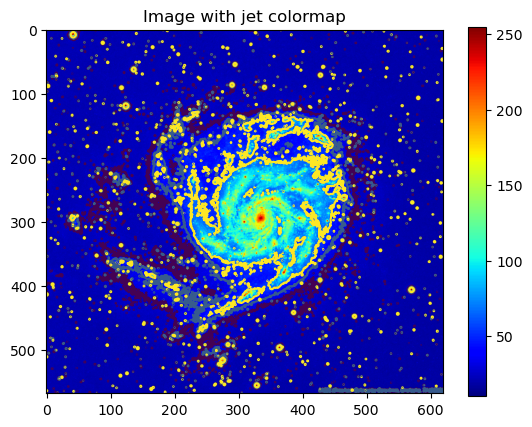

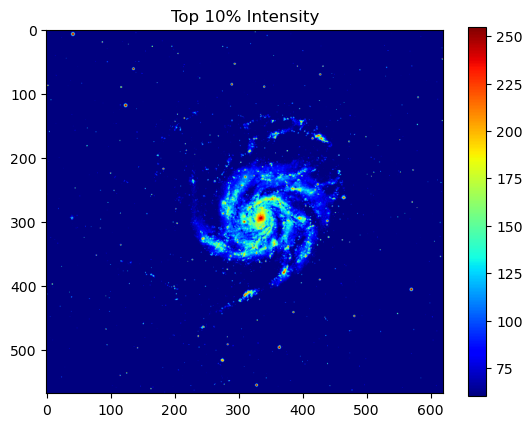

In [58]:
import numpy as np
import imageio
import matplotlib.pyplot as plt

# To read the data in a NumPy array
image = imageio.imread("m101BW.jpg")  

# Show image with colormap jet
plt.figure()
levels = np.percentile(image, [70,80,90])
plt.contour(image, levels=levels)
plt.imshow(image, cmap="jet")
plt.colorbar()
plt.title("Image with jet colormap")
plt.show()


# Keep highest 10% intensities
Filter = np.percentile(image, 90)

filtered = np.where(image >= Filter, image, Filter)  # New filtered image

plt.figure()
plt.imshow(filtered, cmap="jet")
plt.colorbar()
plt.title("Top 10% Intensity")
plt.show()

z statistics:
Max: 0.0606
Min: 0.00482
Sum: 0.89154
Mean: 0.0222885
Std: 0.012699434544498428


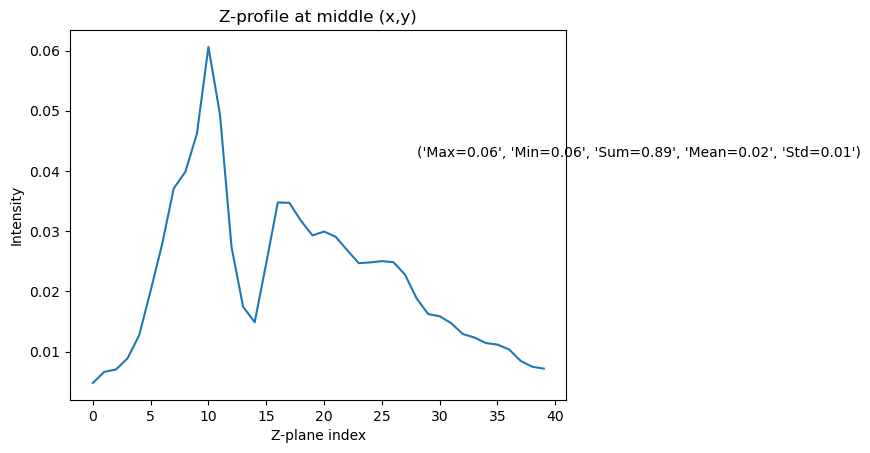

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ngc6946.txt")

cube = data.reshape(40, 50, 70) # Reshape into cube (z, y, x)

y_mid = 50 // 2   
x_mid = 70 // 2   

z_profile = cube[:, y_mid, x_mid]

z_max = np.max(z_profile)
z_min = np.min(z_profile)
z_sum = np.sum(z_profile)
z_mean = np.mean(z_profile)
z_std = np.std(z_profile)

print("z statistics:")
print("Max:", z_max)
print("Min:", z_min)
print("Sum:", z_sum)
print("Mean:", z_mean)
print("Std:", z_std)

plt.figure()
plt.plot(z_profile)
plt.title("Z-profile at middle (x,y)")
plt.xlabel("Z-plane index")
plt.ylabel("Intensity")

# Add statistics text on plot
stats_text = (f"Max={z_max:.2f}", 
              f"Min={z_max:.2f}", 
              f"Sum={z_sum:.2f}", 
              f"Mean={z_mean:.2f}", 
              f"Std={z_std:.2f}") 
              
plt.text(0.7*len(z_profile), z_max*0.7, stats_text)

plt.show()

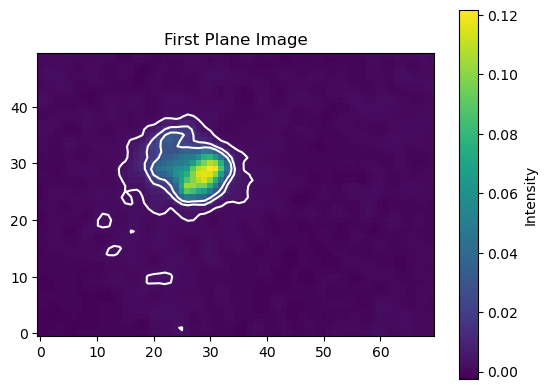

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ngc6946.txt")

cube = data.reshape(40, 50, 70) # Reshape into cube (z, y, x)

first_plane = cube[0]

mean_val = np.mean(first_plane)
std_val = np.std(first_plane)

plt.figure()
im = plt.imshow(first_plane, origin='lower')
plt.colorbar(im, label='Intensity')
plt.title("First Plane Image")

contour_levels = [mean_val, mean_val + std_val, mean_val + 2*std_val]

plt.contour(first_plane, levels=contour_levels, colors='white')
plt.show()

In [28]:
import scipy.constants as const

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c = const.c         # Speed of light in m/s (class variable)
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z

    def velocity(self):
        z = self.redshift()
        v = z * self.c        # velocity in m/s
        return v / 1000       # convert to km/s

galaxy1 = Galaxy("Example galaxy", 5000)

print("Galaxy:", galaxy1.name)
print("Redshift:", galaxy1.redshift())
print("Velocity in km/s:", galaxy1.velocity())

Galaxy: Example galaxy
Redshift: 0.2063
Velocity in km/s: 61847.184085400004


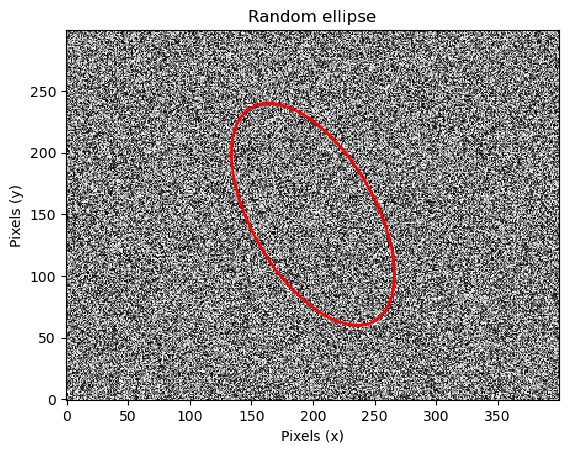

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import show
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

fig, ax = plt.subplots()

ax.imshow(data, interpolation='none', origin='lower', cmap='gray')

x_center = Nx / 2
y_center = Ny / 2

# Create ellipse
ellipse = Ellipse((x_center, y_center), width=2*50, height=2*100, angle=30.0, edgecolor='red', facecolor='none', linewidth=2)

# Add ellipse to plot
ax.add_patch(ellipse)

ax.set_title("Random ellipse")
ax.set_xlabel("Pixels (x)")
ax.set_ylabel("Pixels (y)")

show()